# Faraday complexity of 1, is really zero

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import h5py
from scipy.ndimage import map_coordinates

In [2]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

NameError: name 'whamIntegrated' is not defined

In [3]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

In [4]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits' 
eightsigmapeaksdat = fits.getdata(fn)
eightsigmapeakdshdr = fits.getheader(fn)
fn1 = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits' 
eightsigmapeakscardat = fits.getdata(fn1)
eightsigmapeakscarhdr = fits.getheader(fn1)

(70.0, 90.0)

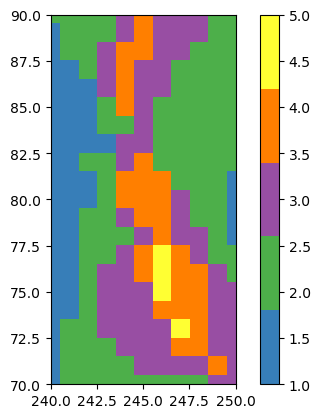

In [5]:
fig, ax = plt.subplots(1,1) 
im = ax.imshow(eightsigmapeakscardat, 
               cmap = Set11, vmin =1, vmax = 5,
               origin = 'lower'
              )
plt.colorbar(im)
ax.set_xlim(240,250)
ax.set_ylim(70,90)

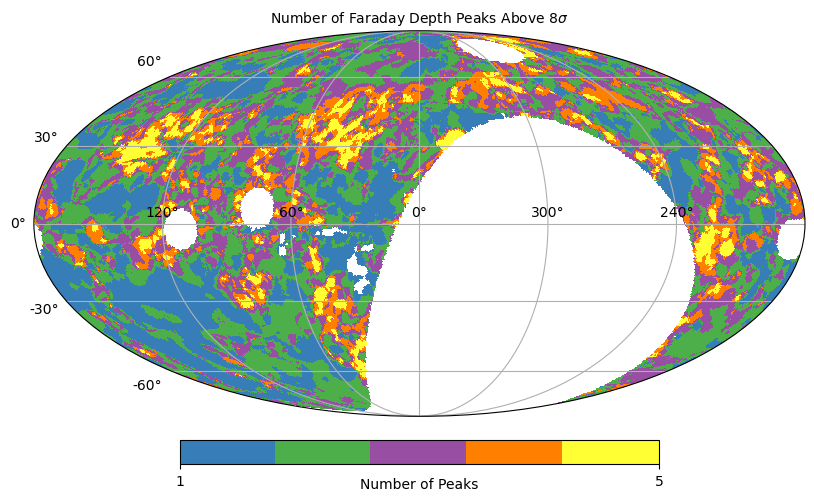

In [6]:
projview(
    eightsigmapeaksdat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = Set11,
    min = 1, 
    max = 5,
    unit = r'Number of Peaks',
    title = r'Number of Faraday Depth Peaks Above 8$\sigma$', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [7]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits'
Npeakscardat = fits.getdata(fn)
Npeakscarhdr = fits.getheader(fn)

In [8]:
#loading dirty Faraday Depth Cube for spectra
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.car.fits'
FDdirtydat = fits.getdata(fn)
FDdirtyhdr = fits.getheader(fn)

In [9]:
#loading clean Faraday Depth Cube for spectra from DRAGONS
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_clean_tot_Kgal.car.fits'
FDcleandat = fits.getdata(fn) 
FDcleanhdr = fits.getheader(fn)

In [10]:
wcs = WCS(FDcleanhdr)
wcs

WCS Keywords

Number of WCS axes: 3
CTYPE : 'GLON-CAR' 'GLAT-CAR' 'FDEP'
CUNIT : 'deg' 'deg' 'rad / m2'
CRVAL : 0.0 0.0 0.0
CRPIX : 360.5 180.5 401.0
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0
CDELT : -0.5 0.5 0.5
NAXIS : 720  360  801

In [11]:
FDcleanhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  801                                                  
COORDSYS= 'Galactic '          / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'K/RMSF  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                   

In [12]:
Npeakscarhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
COORDSYS= 'galactic'           / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'NUMBER  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                    0                                                  
CTYPE1  = 'GLON-CAR'        

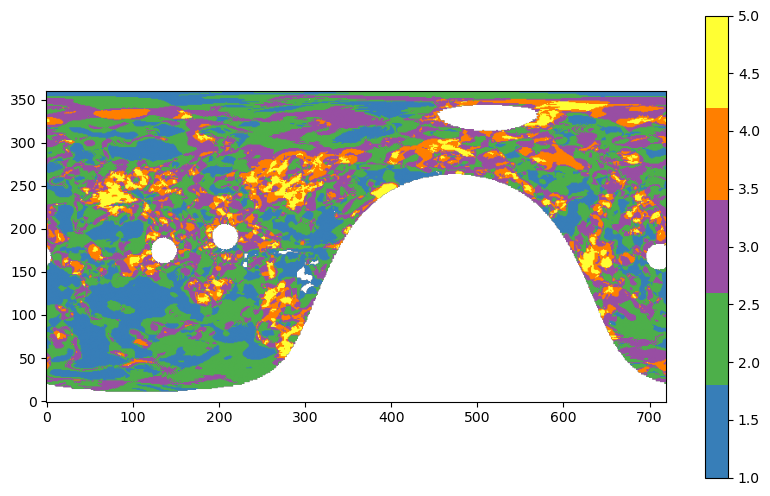

In [13]:
figsize = (10, 6)
fig, ax = plt.subplots(1,1, figsize = figsize)#, subplot_kw={'projection'})#: wcs.celestial})
im0 = ax.imshow(Npeakscardat, origin='lower', cmap = Set11, vmin=1, vmax=5)

plt.colorbar(im0)
plt.show()

In [14]:
mask = (Npeakscardat == 0)

y_indices, x_indices = np.where(mask)

zero_comp_pix_coord = list(zip(x_indices, y_indices)) 

print(len(zero_comp_pix_coord), zero_comp_pix_coord[:5])

0 []


# Finding lines of sight with given faraday complexity, as well as the regions with this complexity. Region here, defined as an area greater than or equal to 59 square pixels. Based on the beam area of the 15 m telescope at DRAO

## faraday complexity: 1

In [15]:
wcs = WCS(Npeakscarhdr)

In [16]:
mask = (0 < Npeakscardat) & (Npeakscardat < 2)

yIndices, xIndices = np.where(mask)

oneCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(oneCompPixCoord), oneCompPixCoord[:5]) 

37695 [[113  12]
 [114  12]
 [115  12]
 [116  12]
 [133  12]]


In [17]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(oneCompPixCoord)))
newLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(oneCompPixCoord[currentIndex])]
    queue = [oneCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = oneCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(oneCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(oneCompPixCoord[actualIdx])
        
        newLoS.append(currentRegion)

minimumPixArea = 59 
resolvedRegions = [r for r in newLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(resolvedRegions)}, distinct lines of sight: {len(newLoS)}")

Number of regions: 36726, distinct lines of sight: 37684


In [20]:
chunkSize = 1000

with h5py.File("galCoords.h5", "w") as f: 
    for regionIdx, region in enumerate(resolvedRegions):
        regionArray = np.array(region, dtype=np.int32)
        lChunks=[]
        bChunks=[]
        for i in range(0, len(regionArray), chunkSize):
            chunk = regionArray[i:i + chunkSize]
            skyCoords = wcs.pixel_to_world(chunk[:,0], chunk[:,1])
            galCoords = skyCoords.galactic
            lChunks.append(galCoords.l.deg.astype(np.float32))
            bChunks.append(galCoords.b.deg.astype(np.float32))
            del skyCoords, galCoords, chunk 
        galArray = np.column_stack((np.concatenate(lChunks), np.concatenate(bChunks)))
        f.create_dataset(f"region{regionIdx}", data=galArray)
        del regionArray, galArray, lChunks, bChunks
print("Done. Access later with h5py.")

Done. Access later with h5py.


In [22]:
#reserved for h5py access
with h5py.File("galCoords.h5", "r") as f:
    region0 = f["region0"][:] 

## faraday depth = 2

In [18]:
mask = (1 < Npeakscardat) & (Npeakscardat < 3)

yIndices, xIndices = np.where(mask)

twoCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(twoCompPixCoord), twoCompPixCoord[:5]) 

60185 [[69 12]
 [70 12]
 [71 12]
 [72 12]
 [73 12]]


In [19]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(twoCompPixCoord)))
compTwoNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(twoCompPixCoord[currentIndex])]
    queue = [twoCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = twoCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(twoCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(twoCompPixCoord[actualIdx])
        
        compTwoNewLoS.append(currentRegion)

minimumPixArea = 59 
compTwoResolvedRegions = [r for r in compTwoNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compTwoResolvedRegions)}, distinct lines of sight: {len(compTwoNewLoS)}")

Number of regions: 59972, distinct lines of sight: 60153


In [25]:
chunkSize = 1000

with h5py.File("compTwoGalCoords.h5", "w") as f: 
    for regionIdx, region in enumerate(compTwoResolvedRegions):
        regionArray = np.array(region, dtype=np.int32)
        lChunks=[]
        bChunks=[]
        for i in range(0, len(regionArray), chunkSize):
            chunk = regionArray[i:i + chunkSize]
            skyCoords = wcs.pixel_to_world(chunk[:,0], chunk[:,1])
            galCoords = skyCoords.galactic
            lChunks.append(galCoords.l.deg.astype(np.float32))
            bChunks.append(galCoords.b.deg.astype(np.float32))
            del skyCoords, galCoords, chunk 
        galArray = np.column_stack((np.concatenate(lChunks), np.concatenate(bChunks)))
        f.create_dataset(f"region{regionIdx}", data=galArray)
        del regionArray, galArray, lChunks, bChunks
print("Done. Access later with h5py.")

KeyboardInterrupt: 

In [ ]:
#reserved for h5py access
#
#
#
#
#

## Faraday depth = 3

In [20]:
mask = (2 < Npeakscardat) & (Npeakscardat < 4)

yIndices, xIndices = np.where(mask)

threeCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(threeCompPixCoord), threeCompPixCoord[:5]) 

45373 [[55 13]
 [57 13]
 [58 13]
 [59 13]
 [60 13]]


In [21]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(threeCompPixCoord)))
compThreeNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(threeCompPixCoord[currentIndex])]
    queue = [threeCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = threeCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(threeCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(threeCompPixCoord[actualIdx])
        
        compThreeNewLoS.append(currentRegion)

minimumPixArea = 59 
compThreeResolvedRegions = [r for r in compThreeNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compThreeResolvedRegions)}, distinct lines of sight: {len(compThreeNewLoS)}")

Number of regions: 45125, distinct lines of sight: 45371


In [22]:
compThreeRegionGalCoords = []
for region in compThreeResolvedRegions:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compThreeRegionGalCoords.append(galArray)

print(f"Example region galactic coords (first 3 pixels):\n{regionGalCoords[0][:3]}")

KeyboardInterrupt: 

## faraday depth = 4

In [23]:
mask = (3 < Npeakscardat) & (Npeakscardat < 5)

yIndices, xIndices = np.where(mask)

fourCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fourCompPixCoord), fourCompPixCoord[:5]) 

18940 [[32 25]
 [33 25]
 [34 25]
 [35 25]
 [36 25]]


In [24]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fourCompPixCoord)))
compFourNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fourCompPixCoord[currentIndex])]
    queue = [fourCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fourCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fourCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fourCompPixCoord[actualIdx])
        
        compFourNewLoS.append(currentRegion)

minimumPixArea = 59 
compFourResolvedRegions = [r for r in compFourNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFourResolvedRegions)}, distinct lines of sight: {len(compFourNewLoS)}")

Number of regions: 18227, distinct lines of sight: 18920


In [91]:
wcs = WCS(Npeakscarhdr)
compFourLoSGalCoords = []
for region in compFourNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFourLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFourLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFourLoSGalCoords[0]},\n{compFourLoSGalCoords[17]}")

Number of LoS: 18920
Example LoS galactic coords 
[[163.75 -77.25]
 [160.25 -77.25]
 [160.75 -77.25]
 [161.25 -77.25]
 [161.75 -77.25]
 [162.25 -77.25]
 [162.75 -77.25]
 [163.25 -77.25]],
[[181.25 -73.75]
 [180.75 -70.25]
 [181.25 -70.25]
 [181.75 -70.25]
 [180.25 -70.75]
 [180.75 -70.75]
 [181.25 -70.75]
 [181.75 -70.75]
 [182.25 -70.75]
 [182.75 -70.75]
 [180.25 -71.25]
 [180.75 -71.25]
 [181.25 -71.25]
 [181.75 -71.25]
 [182.25 -71.25]
 [182.75 -71.25]
 [183.25 -71.25]
 [180.25 -71.75]
 [180.75 -71.75]
 [181.25 -71.75]
 [181.75 -71.75]
 [182.25 -71.75]
 [181.75 -72.25]
 [181.25 -73.25]
 [181.75 -73.25]
 [180.75 -73.75]
 [181.25 -66.75]
 [181.75 -67.25]
 [182.25 -67.25]
 [182.25 -67.75]
 [182.75 -67.75]
 [183.25 -67.75]
 [180.25 -68.25]
 [180.75 -68.25]
 [181.75 -68.25]
 [182.25 -68.25]
 [182.75 -68.25]
 [183.25 -68.25]
 [180.25 -68.75]
 [180.75 -68.75]
 [181.25 -68.75]
 [181.75 -68.75]
 [182.25 -68.75]
 [182.75 -68.75]
 [183.25 -68.75]
 [183.75 -68.75]
 [180.25 -69.25]
 [180.75 -69.

## faraday depth = 5

In [25]:
mask = (4 < Npeakscardat) & (Npeakscardat < 6)

yIndices, xIndices = np.where(mask)

fiveCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fiveCompPixCoord), fiveCompPixCoord[:5]) 

5602 [[ 95  42]
 [ 97  43]
 [697  45]
 [272  53]
 [273  53]]


In [26]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fiveCompPixCoord)))
compFiveNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fiveCompPixCoord[currentIndex])]
    queue = [fiveCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fiveCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fiveCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fiveCompPixCoord[actualIdx])
        
        compFiveNewLoS.append(currentRegion)

minimumPixArea = 59 
compFiveResolvedRegions = [r for r in compFiveNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFiveResolvedRegions)}, distinct lines of sight: {len(compFiveNewLoS)}")

Number of regions: 4449, distinct lines of sight: 5593


In [88]:
wcs = WCS(Npeakscarhdr)
compFiveLoSGalCoords = []
for region in compFiveNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFiveLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFiveLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFiveLoSGalCoords[0]},\n{compFiveLoSGalCoords[17]}")

Number of LoS: 5593
Example LoS galactic coords 
[[132.25 -68.75]
 [131.25 -68.25]],
[[ 43.75 -63.25]
 [ 43.75 -59.75]
 [ 44.25 -59.75]
 [ 42.25 -60.25]
 [ 42.75 -60.25]
 [ 43.75 -60.25]
 [ 41.25 -60.75]
 [ 41.75 -60.75]
 [ 42.25 -60.75]
 [ 42.75 -60.75]
 [ 43.25 -60.75]
 [ 43.75 -60.75]
 [ 44.25 -60.75]
 [ 42.25 -61.25]
 [ 42.75 -61.25]
 [ 42.25 -61.75]
 [ 42.75 -61.75]
 [ 43.25 -61.75]
 [ 43.75 -61.75]
 [ 44.25 -61.75]
 [ 44.75 -61.75]
 [ 40.75 -62.25]
 [ 41.25 -62.25]
 [ 41.75 -62.25]
 [ 42.25 -62.25]
 [ 42.75 -62.25]
 [ 43.25 -62.25]
 [ 43.75 -62.25]
 [ 40.75 -62.75]
 [ 41.25 -62.75]
 [ 41.75 -62.75]
 [ 42.25 -62.75]
 [ 42.75 -62.75]
 [ 43.25 -62.75]
 [ 43.75 -62.75]
 [ 40.75 -63.25]
 [ 41.25 -63.25]
 [ 41.75 -63.25]
 [ 42.25 -63.25]
 [ 42.75 -63.25]
 [ 43.25 -63.25]
 [ 42.25 -56.75]
 [ 42.75 -56.75]
 [ 45.25 -56.75]
 [ 41.75 -57.25]
 [ 45.75 -57.25]
 [ 46.25 -57.25]
 [ 46.25 -57.75]
 [ 42.25 -58.25]
 [ 42.75 -58.25]
 [ 43.25 -58.25]
 [ 43.75 -58.25]
 [ 44.25 -58.25]
 [ 41.25 -58.7

## complexity = 6

In [28]:
mask = (5 < Npeakscardat) & (Npeakscardat < 7)
yIndices, xIndices = np.where(mask)

sixCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sixCompPixCoord), sixCompPixCoord[:5]) 

1250 [[276  56]
 [277  56]
 [278  56]
 [279  56]
 [280  56]]


In [29]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sixCompPixCoord)))
compSixNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sixCompPixCoord[currentIndex])]
    queue = [sixCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sixCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sixCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sixCompPixCoord[actualIdx])
        
        compSixNewLoS.append(currentRegion)

minimumPixArea = 59 
compSixResolvedRegions = [r for r in compSixNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSixResolvedRegions)}, distinct lines of sight: {len(compSixNewLoS)}")

Number of regions: 737, distinct lines of sight: 1217


In [75]:
wcs = WCS(Npeakscarhdr)
compSixLoSGalCoords = []
for region in compSixNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSixLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSixLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSixLoSGalCoords[0]},\n{compSixLoSGalCoords[17]}")

Number of LoS: 1217
Example LoS galactic coords 
[[ 41.75 -61.75]
 [ 41.25 -58.25]
 [ 41.75 -58.25]
 [ 40.25 -58.75]
 [ 40.75 -58.75]
 [ 39.75 -59.25]
 [ 40.25 -59.25]
 [ 40.75 -59.25]
 [ 41.25 -59.25]
 [ 43.75 -59.25]
 [ 44.25 -59.25]
 [ 39.25 -59.75]
 [ 39.75 -59.75]
 [ 40.25 -59.75]
 [ 40.75 -59.75]
 [ 42.75 -59.75]
 [ 43.25 -59.75]
 [ 38.75 -60.25]
 [ 39.25 -60.25]
 [ 39.75 -60.25]
 [ 43.25 -60.25]
 [ 39.25 -61.25]
 [ 39.75 -61.25]
 [ 40.25 -61.25]
 [ 40.75 -61.25]
 [ 41.25 -61.25]
 [ 41.75 -61.25]
 [ 39.25 -61.75]
 [ 39.75 -61.75]
 [ 40.25 -61.75]
 [ 40.75 -61.75]
 [ 41.25 -61.75]
 [ 41.25 -54.75]
 [ 41.25 -55.25]
 [ 40.75 -55.75]
 [ 41.25 -55.75]
 [ 39.75 -56.25]
 [ 40.25 -56.25]
 [ 40.75 -56.25]
 [ 41.25 -56.25]
 [ 39.25 -56.75]
 [ 39.75 -56.75]
 [ 41.25 -56.75]
 [ 38.75 -57.25]
 [ 39.25 -57.25]
 [ 39.75 -57.25]
 [ 40.25 -57.25]
 [ 40.75 -57.25]
 [ 38.75 -57.75]
 [ 39.25 -57.75]
 [ 39.75 -57.75]
 [ 40.25 -57.75]
 [ 40.75 -57.75]
 [ 41.25 -57.75]
 [ 41.75 -57.75]
 [ 39.25 -58.25]

## faraday depth = 7 

In [31]:
mask = (6 < Npeakscardat) & (Npeakscardat < 8)

yIndices, xIndices = np.where(mask)

sevenCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sevenCompPixCoord), sevenCompPixCoord[:5]) 

242 [[277  65]
 [278  66]
 [279  66]
 [641 103]
 [642 103]]


In [32]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sevenCompPixCoord)))
compSevenNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sevenCompPixCoord[currentIndex])]
    queue = [sevenCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sevenCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sevenCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sevenCompPixCoord[actualIdx])
        
        compSevenNewLoS.append(currentRegion)

minimumPixArea = 59 
compSevenResolvedRegions = [r for r in compSevenNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSevenResolvedRegions)}, distinct lines of sight: {len(compSevenNewLoS)}")

Number of regions: 68, distinct lines of sight: 241


In [73]:
wcs = WCS(Npeakscarhdr)
compSevenLoSGalCoords = []
for region in compSevenNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSevenLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSevenLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSevenLoSGalCoords[0]},\n{compSevenLoSGalCoords[17]}")

Number of LoS: 241
Example LoS galactic coords 
[[ 41.25 -57.25]
 [ 40.25 -56.75]
 [ 40.75 -56.75]],
[[228.25 -12.75]
 [226.75  -9.75]
 [227.25  -9.75]
 [227.75  -9.75]
 [225.75 -10.25]
 [226.25 -10.25]
 [227.25 -10.25]
 [227.75 -10.75]
 [227.25 -11.25]
 [227.75 -11.25]
 [228.25 -11.25]
 [227.25 -11.75]
 [227.75 -11.75]
 [228.25 -11.75]
 [227.25 -12.25]
 [227.75 -12.25]
 [228.25 -12.25]
 [228.75 -12.25]
 [226.75 -12.75]
 [227.25 -12.75]
 [227.75 -12.75]
 [224.25  -7.75]
 [223.75  -8.25]
 [224.25  -8.25]
 [223.75  -4.25]
 [222.75  -4.75]
 [223.25  -7.25]
 [222.75  -3.75]
 [223.25  -3.75]
 [223.75  -3.75]
 [222.75  -4.25]
 [223.25  -4.25]]


## complexity = 8

In [34]:
mask = (7 < Npeakscardat) & (Npeakscardat < 9)

yIndices, xIndices = np.where(mask)

eightCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(eightCompPixCoord), eightCompPixCoord[:5]) 

19 [[704 213]
 [705 214]
 [705 215]
 [675 216]
 [676 216]]


In [35]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(eightCompPixCoord)))
compEightNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(eightCompPixCoord[currentIndex])]
    queue = [eightCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = eightCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(eightCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(eightCompPixCoord[actualIdx])
        
        compEightNewLoS.append(currentRegion)

minimumPixArea = 59 
compEightResolvedRegions = [r for r in compEightNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compEightResolvedRegions)}, distinct lines of sight: {len(compEightNewLoS)}")

Number of regions: 0, distinct lines of sight: 18


In [36]:
compEightLoSGalCoords = []
for region in compEightNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compEightLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compEightLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compEightLoSGalCoords[0]},\n{compEightLoSGalCoords[17]}")

Number of LoS: 18
Example LoS galactic coords 
[[187.75  16.75]
 [186.75  18.25]
 [187.25  17.75]
 [187.25  17.25]],
[[342.75  32.75]]


In [54]:
len(compEightRegionGalCoords)

90

In [46]:
totalDetectedPixels = np.sum(Npeakscardat > 1)
complexPixels = np.sum(Npeakscardat > 2)

print(f"Total detected pixels: {totalDetectedPixels}")
print(f"Complex pixels: {complexPixels}")
print(f"Percentage complex: {complexPixels/totalDetectedPixels * 100:.2f}%")

Total detected pixels: 131611
Complex pixels: 71426
Percentage complex: 54.27%


# Plotting

In [47]:
y = np.array([len(one_comp_pix_coord), len(two_comp_pix_coord), len(three_comp_pix_coord), len(four_comp_pix_coord), len(five_comp_pix_coord), len(six_comp_pix_coord), len(seven_comp_pix_coord), len(eight_comp_pix_coord)])
x = np.array([1, 2, 3, 4, 5, 6 ,7 ,8])
plt.scatter(x, y)

NameError: name 'one_comp_pix_coord' is not defined

In [48]:
y = np.array([len(one_comp_pix_coord), len(two_comp_pix_coord), len(three_comp_pix_coord), len(four_comp_pix_coord), len(five_comp_pix_coord), len(six_comp_pix_coord), len(seven_comp_pix_coord), len(eight_comp_pix_coord)])
x = np.array([1, 2, 3, 4, 5, 6 ,7 ,8])
plt.bar(x, y)

NameError: name 'one_comp_pix_coord' is not defined

<BarContainer object of 8 artists>

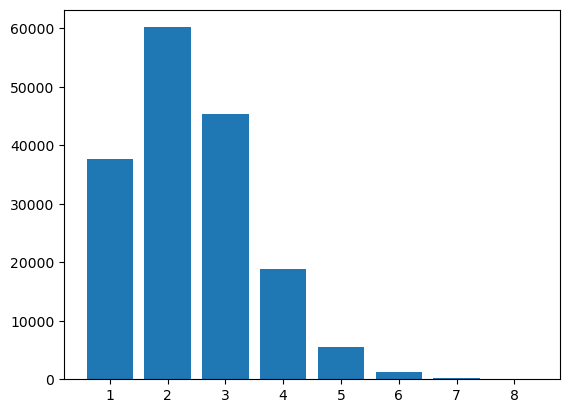

In [49]:
y = np.array([len(newLoS), len(compTwoNewLoS), len(compThreeNewLoS), len(compFourNewLoS), len(compFiveNewLoS), len(compSixNewLoS), len(compSevenNewLoS), len(compEightNewLoS)])
x = np.array([1, 2, 3, 4, 5, 6 ,7 ,8])
plt.bar(x, y)

# starting statistics sort of, at least doing a mean 

In [58]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

In [60]:
#putting velo axis in km/s 
nVel = whamhdr['NAXIS3']
crval3 = whamhdr['CRVAL3']
crpix3 = whamhdr['CRPIX3']
cdelt3 = whamhdr['CDELT3']

velAxis = (crval3 + (np.arange(nVel) - (crpix3 -1)) * cdelt3) / 1000
print(f"Velocity range: {velAxis[0]:.1f} to {velAxis[-1]:.1f} km/s")

Velocity range: -169.1 to 157.3 km/s


In [62]:
#masking for local velocities 
velMask = (velAxis >= -80) & (velAxis <= 80)
velMask.sum()

np.int64(79)

In [63]:
whamIntegrated = np.nansum(whamdat[velMask, :, :] * abs(cdelt3), axis=0) / 1000


In [64]:
print(f"NaN count: {np.sum(np.isnan(whamdat))}")
print(f"Zero count: {np.sum(whamdat == 0)}")
print(f"Data range: {np.nanmin(whamdat):.4f} to {np.nanmax(whamdat):.4f}")
print(f"Integrated map range: {np.nanmin(whamIntegrated):.4f} to {np.nanmax(whamIntegrated):.4f}")

NaN count: 65383544
Zero count: 0
Data range: -0.0994 to 77.8963
Integrated map range: -1.3497 to 4417.2949


In [65]:
print(f"Channels selected: {velMask.sum()}")
print(f"Velocity range used: {velAxis[velMask][0]:.1f} to {velAxis[velMask][-1]:.1f} km/s")

Channels selected: 79
Velocity range used: -79.9 to 78.2 km/s


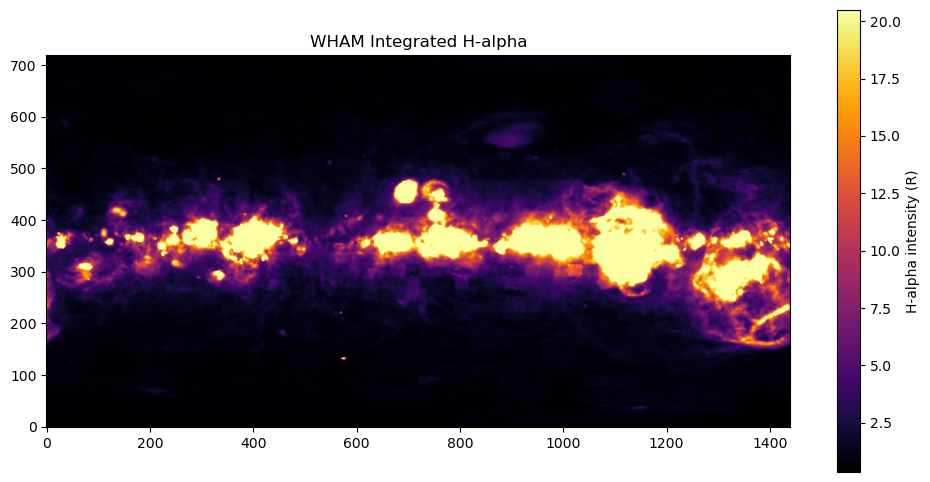

In [66]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

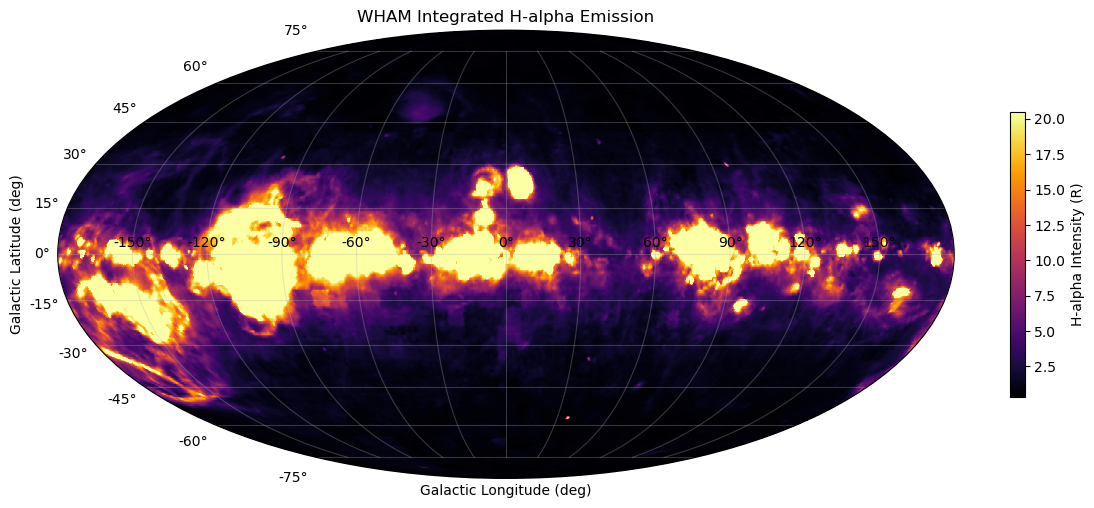

In [67]:
lon = np.linspace(180, -180, whamIntegrated.shape[1])
lat = np.linspace(-90, 90, whamIntegrated.shape[0])
lonGrid, latGrid = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
img = ax.pcolormesh(lonGrid, latGrid, whamIntegrated, cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='H-alpha Intensity (R)', shrink=0.5)
ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
ax.grid(True, alpha=0.3)
plt.title('WHAM Integrated H-alpha Emission')
plt.tight_layout()
plt.show()

In [80]:
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compEightLoSGalCoords) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

whamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(whamSampled)} LoS")
print(f"H-alpha intensity range: {whamSampled.min():.2f} to {whamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {whamSampled.mean():.2f}")

Sampled 78 LoS
H-alpha intensity range: 1.16 to 4.23
Mean H-alpha intensity: 2.94


In [81]:
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compSevenLoSGalCoords) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

whamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(whamSampled)} LoS")
print(f"H-alpha intensity range: {whamSampled.min():.2f} to {whamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {whamSampled.mean():.2f}")

Sampled 8758 LoS
H-alpha intensity range: 0.41 to 13.17
Mean H-alpha intensity: 2.36


In [82]:
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compSixLoSGalCoords) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

whamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(whamSampled)} LoS")
print(f"H-alpha intensity range: {whamSampled.min():.2f} to {whamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {whamSampled.mean():.2f}")

Sampled 117959 LoS
H-alpha intensity range: -1.01 to 160.62
Mean H-alpha intensity: 2.15


In [90]:
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compFiveLoSGalCoords) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

whamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(whamSampled)} LoS")
print(f"H-alpha intensity range: {whamSampled.min():.2f} to {whamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {whamSampled.mean():.2f}")

Sampled 2054073 LoS
H-alpha intensity range: 0.13 to 319.29
Mean H-alpha intensity: 2.28


In [93]:
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compFourLoSGalCoords) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

whamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(whamSampled)} LoS")
print(f"H-alpha intensity range: {whamSampled.min():.2f} to {whamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {whamSampled.mean():.2f}")

Sampled 38324742 LoS
H-alpha intensity range: -0.65 to 301.29
Mean H-alpha intensity: 3.68
